# ADRMiner — Classification and Compliance Analysis

## Purpose

This notebook aggregates and analyzes the outputs produced by the ADRMiner workflow.
It loads the precomputed JSON files generated by the topic-modeling,
taxonomy-classification, and MADR-checking notebooks.

The notebook reproduces the main descriptive and cross-framework analyses reported in
the companion paper:

- category distributions for Kruchten's taxonomy;
- quality-attribute distributions;
- category distributions for Zimmermann's taxonomy;
- cross-framework Sankey diagrams;
- relationships between decision types and mined topics; and
- MADR section-compliance summaries and heatmaps.

## Main inputs

- Curated ADR corpus under `../data/`.
- Taxonomy-classification JSON files under `../results/`.
- Topic-assignment JSON file under `../results/`.
- MADR-checking JSON file under `../results/`.

## Main outputs

- Classification distribution charts.
- Cross-framework Sankey diagrams.
- Topic distribution and mapping charts.
- MADR section-compliance heatmap.

> **Path assumption:** Run this notebook from the repository's `notebooks/` directory.


## 1. Imports

The following cells load the analysis, visualization, and ADRMiner utility modules.
This notebook expects the local `adr.py` and `utils.py` modules to be available in the
current `notebooks/` directory.

In [1]:
import json
import os
import pickle
from itertools import product
from pathlib import Path

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import json_normalize
from sankeyflow import Sankey


In [2]:
from adr import adr
import utils


## 2. Analysis configuration

The following cell defines the paths of the curated dataset and the precomputed result
files used throughout the analysis. The default values correspond to the filenames
distributed with the artifact.

Update an individual path only when analyzing a different result file or dataset.


In [3]:
# Curated corpus used to reproduce the project-level filtering.
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle'

# Precomputed result files distributed with the artifact.
KRUCHTEN_RESULTS = '../results/all_projects-krutchen_classification_results.json'
QUALITY_ATTRIBUTE_RESULTS = '../results/all_projects-qas_classification_results.json'
ZIMMERMANN_RESULTS = '../results/all_projects-zimmermann_classification_results.json'
TOPICS_RESULTS = '../results/all_projects-topics.json'
COMPLIANCE_RESULTS = '../results/all_projects-checks_results.json'

# Topics below this corpus proportion are grouped into "Others".
TOPIC_FREQUENCY_THRESHOLD = 0.02

COMMON_PALETTE = plt.cm.Set3

configured_files = {
    'Kruchten': Path(KRUCHTEN_RESULTS),
    'Quality attributes': Path(QUALITY_ATTRIBUTE_RESULTS),
    'Zimmermann': Path(ZIMMERMANN_RESULTS),
    'Topics': Path(TOPICS_RESULTS),
    'MADR checks': Path(COMPLIANCE_RESULTS),
}

print('Configured result files:')
for label, path in configured_files.items():
    status = 'found' if path.is_file() else 'MISSING'
    print(f' - {label}: {path} [{status}]')


Configured result files:
 - Kruchten: ..\results\all_projects-krutchen_classification_results.json [found]
 - Quality attributes: ..\results\all_projects-qas_classification_results.json [found]
 - Zimmermann: ..\results\all_projects-zimmermann_classification_results.json [found]
 - Topics: ..\results\all_projects-topics.json [found]
 - MADR checks: ..\results\all_projects-checks_results.json [found]


## 3. Visualization helpers

These functions generate the category-distribution charts used throughout the notebook.
They accept a normalized dataframe and the column containing the category labels.

In [4]:
def create_pie_chart(
    df: pd.DataFrame,
    palette,
    title: str = "",
    show_legend: bool = False,
    category_column: str = 'primary_category',
):
    """Plot the percentage distribution of a categorical dataframe column."""
    df_counter = df[category_column].value_counts()

    if show_legend:
        df_counter.plot(
            kind='pie',
            autopct='%1.1f%%',
            cmap=palette,
            labels=None,
        )
        plt.legend(
            df_counter.index,
            loc='upper left',
            bbox_to_anchor=(1, 1),
        )
    else:
        df_counter.plot(
            kind='pie',
            autopct='%1.1f%%',
            cmap=palette,
        )

    plt.title(title)
    plt.ylabel('')
    plt.show()


def create_bar_chart(
    df: pd.DataFrame,
    palette,
    title: str = "",
    show_legend: bool = False,
    category_column: str = "primary_category",
    fig_size=(8, 3),
    col_width: float = 0.8,
):
    """Plot normalized category frequencies as horizontal percentages."""
    percentages = (
        df[category_column]
        .value_counts(normalize=True)
        .mul(100)
        .sort_values(ascending=True)
    )

    plt.figure(figsize=fig_size)
    my_colors = [colors.to_hex(rgba) for rgba in palette.colors]
    ax = percentages.plot(
        kind='barh',
        width=col_width,
        color=my_colors,
    )

    for index, value in enumerate(percentages):
        ax.text(
            value,
            index,
            f'{value:.1f}%',
            va='center',
            ha='left',
            fontsize=10,
        )

    plt.title(title)
    plt.xlim(0, 100)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()


## 4. Load the curated ADR corpus

The corpus is loaded to reproduce the project filtering used in the study and to report
the number of ADRs covered by the analysis. The classification and compliance figures
themselves are generated from the JSON result files configured above.

In [5]:
# Resolve the dataset relative to the notebooks/ directory.
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path, 'rb') as file:
    dict_adrs = pickle.load(file)

print(len(dict_adrs), 'top-level organizations/projects loaded')

# Reproduce the project inclusion criteria used in the companion study.
projects_dict = utils.process_projects(
    dict_adrs,
    min_adrs_per_project=5,
    min_adr_length=500,
)
valid_projects = projects_dict['valid_projects']

docs = utils.get_documents(
    valid_projects,
    dict_adrs,
    field='raw',
)
print(len(valid_projects), 'valid organization/project pairs')
print(len(docs), 'ADRs considered within valid projects')


547 top-level organizations/projects loaded


organizations:   0%|          | 0/547 [00:00<?, ?it/s]

312 valid organization/project pairs
4316 ADRs considered within valid projects


## 5. Classification using Kruchten's taxonomy

This section loads the Kruchten classification results, normalizes their nested JSON
structure, inspects the available categories, and plots their distribution.

In [6]:
def load_json_results(path, label: str):
    """Load a JSON result file and provide a clear missing-file error."""
    path = Path(path)

    if not path.is_file():
        raise FileNotFoundError(
            f"{label} results were not found at {path}. "
            "Check the configured path and confirm that the result file exists."
        )

    with path.open('r', encoding='utf-8') as file:
        data = json.load(file)

    print(len(data), f"{label} ADR results loaded")
    return data

In [7]:
kruchten_classification_dict_list = load_json_results(
    KRUCHTEN_RESULTS,
    'Kruchten',
)
kruchten_classification_dict_list[:10]


4213 Kruchten ADR results loaded


[{'framework': 'kruchten',
  'primary_category': 'Executive (pericrisis)',
  'explanation': 'The ADR focuses on adopting Lightweight Architectural Decision Records (LADRs) as a recommended practice for documenting decisions and rationale in the development process. It is about how the team works and documents architectural decisions rather than about creating or forbidding specific architectural elements or setting system properties. Therefore, it fits best into the Executive category, which governs development processes and organizational practices. It is not an Existence decision because it does not create or select system elements; not a Ban/Non-Existence decision because it does not forbid elements; and not a Property decision because it does not set system qualities or constraints.',
  'primary_score': 0.9,
  'alternative_categories': ['Existence (ontocrisis)'],
  'alternative_confidence_scores': [0.1],
  'metadata': {'organization': 'chunksnbits',
   'project': 'tooling',
   'adr

In [8]:
# Flatten nested metadata fields such as metadata.adr_key.
kruchten_df = pd.json_normalize(kruchten_classification_dict_list)
kruchten_df

,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.organization,metadata.project,metadata.adr_key
0,kruchten,Executive (pericrisis),The ADR focuses on adopting Lightweight Archit...,0.90,[Existence (ontocrisis)],[0.1],chunksnbits,tooling,0001-use-architectural-decision-records.md
1,kruchten,Executive (pericrisis),The ADR decision is about adopting 'husky' as ...,0.90,[Existence (ontocrisis)],[0.1],chunksnbits,tooling,0002-use-husky-for-git-hooks.md
2,kruchten,Executive (pericrisis),The ADR focuses on standardizing the commit me...,0.90,[Property (diacrisis)],[0.1],chunksnbits,tooling,0003-use-commitizen-commitlint.md
3,kruchten,Executive (pericrisis),The ADR decision is about adopting a tool (sta...,0.85,[Property (diacrisis)],[0.15],chunksnbits,tooling,0004-use-standard-version-for-versioning.md
4,kruchten,Executive (pericrisis),The ADR decision is about adopting TypeScript ...,0.85,[Existence (ontocrisis)],[0.15],chunksnbits,tooling,0005-use-typescript-in-javascript-projects.md
...,...,...,...,...,...,...,...,...,...
4208,kruchten,Property (diacrisis),The ADR defines rules about the behavior of he...,0.85,[Existence (ontocrisis)],[0.15],avniproject,openchs-adr,0009-dos-and-donts-for-building-health-module-...
4209,kruchten,Existence (ontocrisis),The ADR decides that implementation-specific r...,0.85,"[Property (diacrisis), Executive (pericrisis)]","[0.1, 0.05]",avniproject,openchs-adr,0010-all-implementation-rules-will-temporarily...
4210,kruchten,Ban/Non-Existence (anticrisis),The ADR decides to stop using the Forms API to...,0.85,[Existence (ontocrisis)],[0.15],avniproject,openchs-adr,0011-moving-forward-forms-api-will-not-be-used...
4211,kruchten,Existence (ontocrisis),The ADR decision is about creating a generic r...,0.90,[Property (diacrisis)],[0.1],avniproject,openchs-adr,0012-create-a-generic-relationship-framework-t...


In [9]:
# Inspect the categories produced by the selected result set.
print(kruchten_df['primary_category'].dropna().unique())

['Executive (pericrisis)' 'Existence (ontocrisis)' 'Property (diacrisis)'
 'Ban/Non-Existence (anticrisis)']


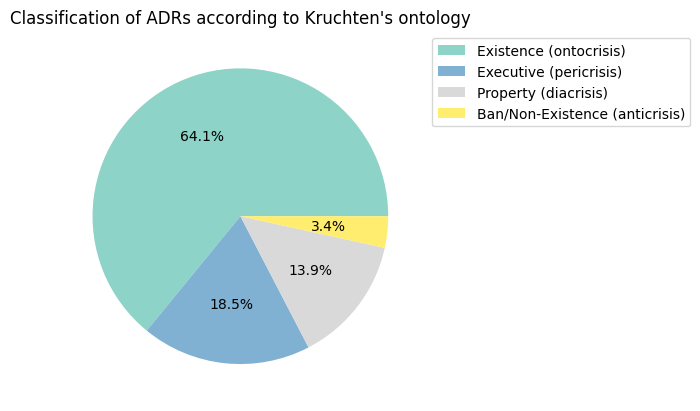

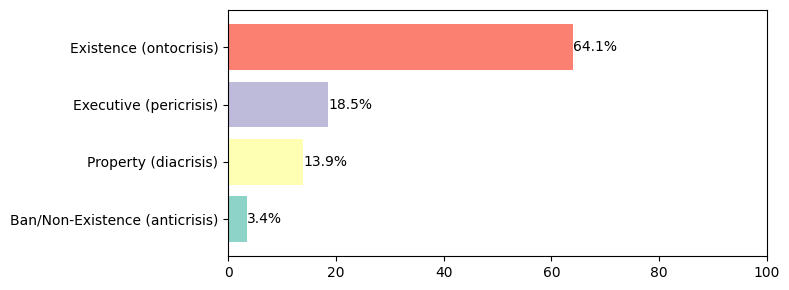

In [10]:
title = "Classification of ADRs according to Kruchten's ontology"

create_pie_chart(
    kruchten_df,
    palette=COMMON_PALETTE,
    show_legend=True,
    title=title,
)
create_bar_chart(
    kruchten_df,
    palette=COMMON_PALETTE,
    title="",
)


## 6. Classification by quality attribute

This section summarizes the primary quality-attribute category assigned to each ADR.
Depending on the classifier configuration, ADRs with predominantly functional concerns
may also appear in this result set.

In [11]:
qa_classification_dict_list = load_json_results(
    QUALITY_ATTRIBUTE_RESULTS,
    'Quality-attribute',
)
qa_classification_dict_list[:10]


4316 Quality-attribute ADR results loaded


[{'framework': 'quality_attributes',
  'primary_category': 'Maintainability',
  'explanation': "The ADR focuses on extending and refactoring the CLI implementation for Konduit Serving by leveraging Vert.x Launcher. The primary motivation is to improve maintainability aspects such as easier testing, lifecycle management, and reducing maintenance overhead by consolidating CLI implementations from Python to Java. Although there are mentions of deployment options and running multiple instances, these are features of the CLI and Vert.x rather than the system's scalability or performance. The core decision is about structuring the CLI codebase and lifecycle, which aligns with Maintainability rather than Performance, Scalability, or other attributes.",
  'primary_score': 0.9,
  'alternative_categories': ['Performance', 'Scalability'],
  'alternative_confidence_scores': [0.07, 0.03],
  'metadata': {'organization': 'KonduitAI',
   'project': 'konduit-serving',
   'adr_key': '0001-Extend_vertx_l

In [12]:
# Flatten nested metadata fields such as metadata.adr_key.
qas_df = pd.json_normalize(qa_classification_dict_list)
qas_df


,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.organization,metadata.project,metadata.adr_key
0,quality_attributes,Maintainability,The ADR focuses on extending and refactoring t...,0.90,"[Performance, Scalability]","[0.07, 0.03]",KonduitAI,konduit-serving,0001-Extend_vertx_launcher_for_CLI.md
1,quality_attributes,Maintainability,The ADR focuses on using Swagger annotations t...,0.90,"[Portability, Usability]","[0.07, 0.03]",KonduitAI,konduit-serving,0002-Use_swagger_annotations_for_generating_cl...
2,quality_attributes,Maintainability,The ADR primarily focuses on redesigning the i...,0.90,"[Performance, Scalability, Usability]","[0.05, 0.03, 0.02]",KonduitAI,konduit-serving,0003-Pipeline_API_Rewrite.md
3,quality_attributes,Maintainability,The ADR primarily focuses on introducing a new...,0.90,"[Performance, Scalability]","[0.07, 0.03]",KonduitAI,konduit-serving,0004-Graph_pipelines.md
4,quality_attributes,Usability,The ADR primarily focuses on improving the usa...,0.85,"[Reliability, Maintainability]","[0.1, 0.05]",KonduitAI,konduit-serving,0005-Packaging_System_Design.md
...,...,...,...,...,...,...,...,...,...
4311,quality_attributes,Maintainability,The ADR focuses on choosing a framework (Ant D...,0.85,"[Usability, Other/Only Functional Concern]","[0.1, 0.05]",dennisseidel,saas-platform-frontend,0007-use-ant-design-landing-to-create-the-land...
4312,quality_attributes,Other/Only Functional Concern,The ADR describes a decision about how to gene...,1.00,[],[],dennisseidel,saas-platform-frontend,0008-use-launchaco-com-to-generate-the-logo-fo...
4313,quality_attributes,Testability,The ADR focuses on the choice of a tool (Cypre...,0.90,"[Maintainability, Other/Only Functional Concern]","[0.07, 0.03]",dennisseidel,saas-platform-frontend,0009-use-cypress-for-e2e-testing.md
4314,quality_attributes,Security,The ADR focuses on the choice of authenticatio...,0.90,"[Usability, Maintainability]","[0.07, 0.03]",dennisseidel,saas-platform-frontend,0010-use-aws-amplify-coginito-for-login-and-th...


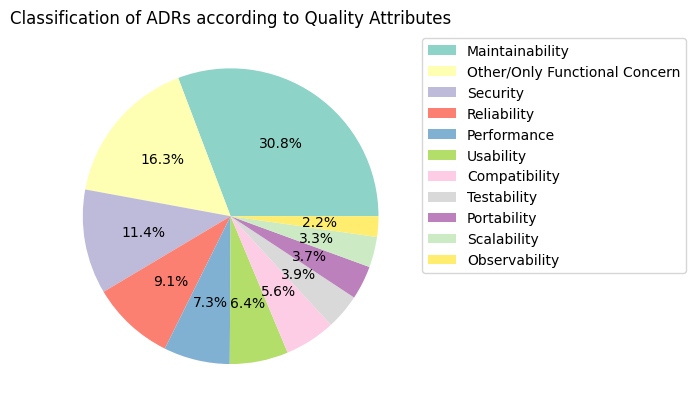

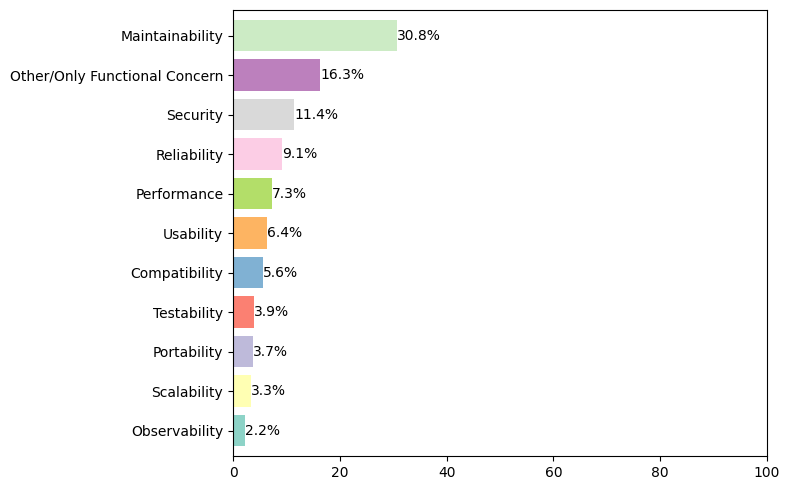

In [13]:
title = "Classification of ADRs according to Quality Attributes"

create_pie_chart(
    qas_df,
    palette=COMMON_PALETTE,
    show_legend=True,
    title=title,
)
create_bar_chart(
    qas_df,
    palette=COMMON_PALETTE,
    title="",
    fig_size=(8, 5),
)


## 7. Classification using Zimmermann's taxonomy

This section summarizes ADRs according to their primary concern, such as design,
technology, infrastructure, organizational/process, or implementation.

In [14]:
zimmermann_classification_dict_list = load_json_results(
    ZIMMERMANN_RESULTS,
    'Zimmermann',
)
zimmermann_classification_dict_list[:5]


4210 Zimmermann ADR results loaded


[{'framework': 'zimmermann',
  'primary_category': 'Organizational/Process',
  'explanation': 'The ADR focuses on the decision to use Architecture Decision Records (ADRs) as a process to document architectural decisions. This is about how the team organizes and records decisions, which is a team workflow/process decision rather than a design, technology, or infrastructure choice. It does not concern system structure, technology selection, or deployment environment, but rather the process of decision documentation, fitting the Organizational/Process category. Other categories like Design or Technology are less appropriate because the ADR is not about system structure or technology selection. Constraint is not applicable as this is a chosen process, not a mandatory imposed rule.',
  'primary_score': 0.85,
  'alternative_categories': ['Design', 'Constraint'],
  'alternative_confidence_scores': [0.1, 0.05],
  'metadata': {'organization': 'navikt',
   'project': 'nada-kafkarator',
   'adr_k

In [15]:
# Flatten nested metadata fields such as metadata.adr_key.
zimmermann_df = pd.json_normalize(
    zimmermann_classification_dict_list
)
zimmermann_df


,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.organization,metadata.project,metadata.adr_key
0,zimmermann,Organizational/Process,The ADR focuses on the decision to use Archite...,0.85,"[Design, Constraint]","[0.1, 0.05]",navikt,nada-kafkarator,0001-record-architecture-decisions.md
1,zimmermann,Technology,The ADR focuses on the selection of Python as ...,0.85,"[Organizational/Process, Implementation]","[0.1, 0.05]",navikt,nada-kafkarator,0002-use-python.md
2,zimmermann,Technology,The ADR focuses on selecting Poetry as the dep...,0.90,[Infrastructure],[0.1],navikt,nada-kafkarator,0003-use-poetry-for-dependency-management.md
3,zimmermann,Design,The ADR discusses the architectural decision t...,0.85,[Implementation],[0.15],navikt,nada-kafkarator,0004-combine-topic-creation-and-credentials-ma...
4,zimmermann,Technology,The ADR focuses on selecting a web framework (...,0.85,"[Design, Quality Attribute]","[0.1, 0.05]",navikt,nada-kafkarator,0005-use-the-fastapi-web-framework.md
...,...,...,...,...,...,...,...,...,...
4205,zimmermann,Organizational/Process,The ADR focuses on how to manage third-party c...,0.85,"[Technology, Design]","[0.1, 0.05]",Internet-of-People,titania-os,0007-layers-as-git-submodules.md
4206,zimmermann,Infrastructure,The ADR describes a deployment and runtime env...,0.85,"[Quality Attribute, Design]","[0.1, 0.05]",Internet-of-People,titania-os,0008-dual-root-with-data-volume.md
4207,zimmermann,Infrastructure,The ADR focuses on placing Docker's state dire...,0.85,[Technology],[0.15],Internet-of-People,titania-os,0009-docker-state-directory-on-data-volume.md
4208,zimmermann,Organizational/Process,The ADR decision is about linking the project'...,0.85,"[Technology, Design]","[0.1, 0.05]",Internet-of-People,titania-os,0010-wiki-as-submodule.md


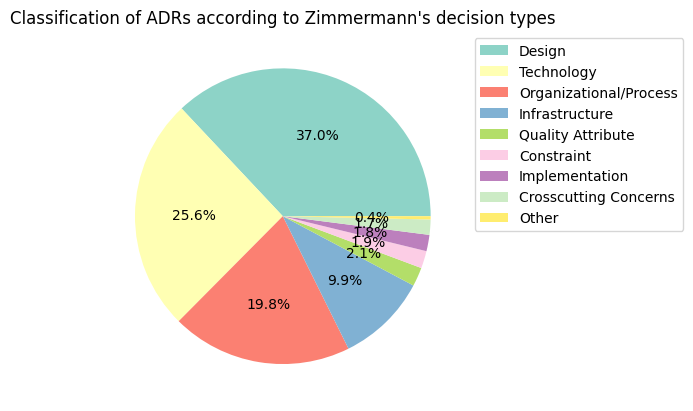

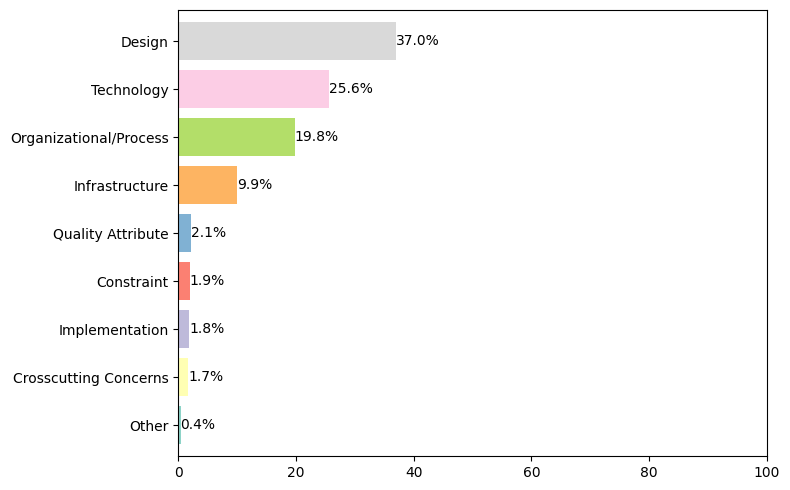

In [16]:
title = "Classification of ADRs according to Zimmermann's decision types"

create_pie_chart(
    zimmermann_df,
    palette=COMMON_PALETTE,
    show_legend=True,
    title=title,
)
create_bar_chart(
    zimmermann_df,
    palette=COMMON_PALETTE,
    title="",
    fig_size=(8, 5),
)


## 8. Cross-framework analyses

The three classification outputs are reduced to their ADR identifier and primary
category. They are then aligned by `adr_key` and visualized using Sankey diagrams.

The diagrams show descriptive co-occurrence patterns; they should not be interpreted as
causal relationships.

In [17]:
# Keep the ADR key and the dominant category from each framework.
kruchten_categories = (
    kruchten_df[['metadata.adr_key', 'primary_category']]
    .dropna()
    .rename(
        columns={
            'metadata.adr_key': 'adr_key',
            'primary_category': 'kruchten_primary_category',
        }
    )
)

qa_categories = (
    qas_df[['metadata.adr_key', 'primary_category']]
    .dropna()
    .rename(
        columns={
            'metadata.adr_key': 'adr_key',
            'primary_category': 'qa_primary_category',
        }
    )
)

zimmermann_categories = (
    zimmermann_df[['metadata.adr_key', 'primary_category']]
    .dropna()
    .rename(
        columns={
            'metadata.adr_key': 'adr_key',
            'primary_category': 'zimmermann_primary_category',
        }
    )
)

print('Kruchten:', kruchten_categories.shape)
print('Quality attributes:', qa_categories.shape)
print('Zimmermann:', zimmermann_categories.shape)


Kruchten: (4213, 2)
Quality attributes: (4316, 2)
Zimmermann: (4210, 2)


In [18]:
# Align classifications by ADR identifier rather than dataframe row order.
classification_df = (
    zimmermann_categories
    .merge(kruchten_categories, on='adr_key', how='inner')
    .merge(qa_categories, on='adr_key', how='inner')
)

print(classification_df.shape, 'ADRs shared by all three result sets')
classification_df.head()


(1771302, 4) ADRs shared by all three result sets


,adr_key,zimmermann_primary_category,kruchten_primary_category,qa_primary_category
0,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
1,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
2,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
3,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
4,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern


In [19]:
# Working dataframe used by the following cross-framework analyses.
mg = classification_df.copy()
mg


,adr_key,zimmermann_primary_category,kruchten_primary_category,qa_primary_category
0,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
1,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
2,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
3,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
4,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern
...,...,...,...,...
1771297,0007-layers-as-git-submodules.md,Organizational/Process,Existence (ontocrisis),Maintainability
1771298,0008-dual-root-with-data-volume.md,Infrastructure,Existence (ontocrisis),Reliability
1771299,0009-docker-state-directory-on-data-volume.md,Infrastructure,Existence (ontocrisis),Maintainability
1771300,0010-wiki-as-submodule.md,Organizational/Process,Existence (ontocrisis),Maintainability


In [20]:
def create_nodes_and_flows(
    df: pd.DataFrame,
    column1: str,
    column2: str,
):
    """Convert two categorical columns into Sankey nodes and flows."""
    values1 = list(df[column1].dropna().unique())
    values2 = list(df[column2].dropna().unique())

    total = df[[column1, column2]].dropna().shape[0]
    if total == 0:
        raise ValueError(
            f'No shared values are available for {column1} and {column2}.'
        )

    nodes1 = [
        (category, int(100 * count / total))
        for category, count in df[column1].value_counts().items()
    ]
    nodes2 = [
        (category, int(100 * count / total))
        for category, count in df[column2].value_counts().items()
    ]

    flows = []
    for value2, value1 in product(values2, values1):
        count = df[
            (df[column2] == value2)
            & (df[column1] == value1)
        ].shape[0]

        if count > 0:
            flows.append(
                (value1, value2, int(count / total * 100))
            )

    return [nodes1, nodes2], flows


def make_sankey(
    nodes,
    flows,
    palette,
    title: str = "",
    figsize=(10, 10),
    fontsize: int = 12,
):
    """Render a Sankey diagram for two classification dimensions."""
    plt.figure(figsize=figsize, dpi=144)
    sankey = Sankey(
        flows=flows,
        flow_color_mode='lesser',
        nodes=nodes,
        cmap=palette,
        node_opts={
            'label_format': '{label} {value}%',
            'label_opts': {'fontsize': fontsize},
        },
    )
    sankey.draw()
    plt.title(title, fontsize=15)
    plt.show()


c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\sankeyflow\sankeyflow.py:72: RuntimeWarning: invalid value encountered in scalar divide
  value_scale = self.value / (self.height - self.flow_pad * (len(flows) - 1))


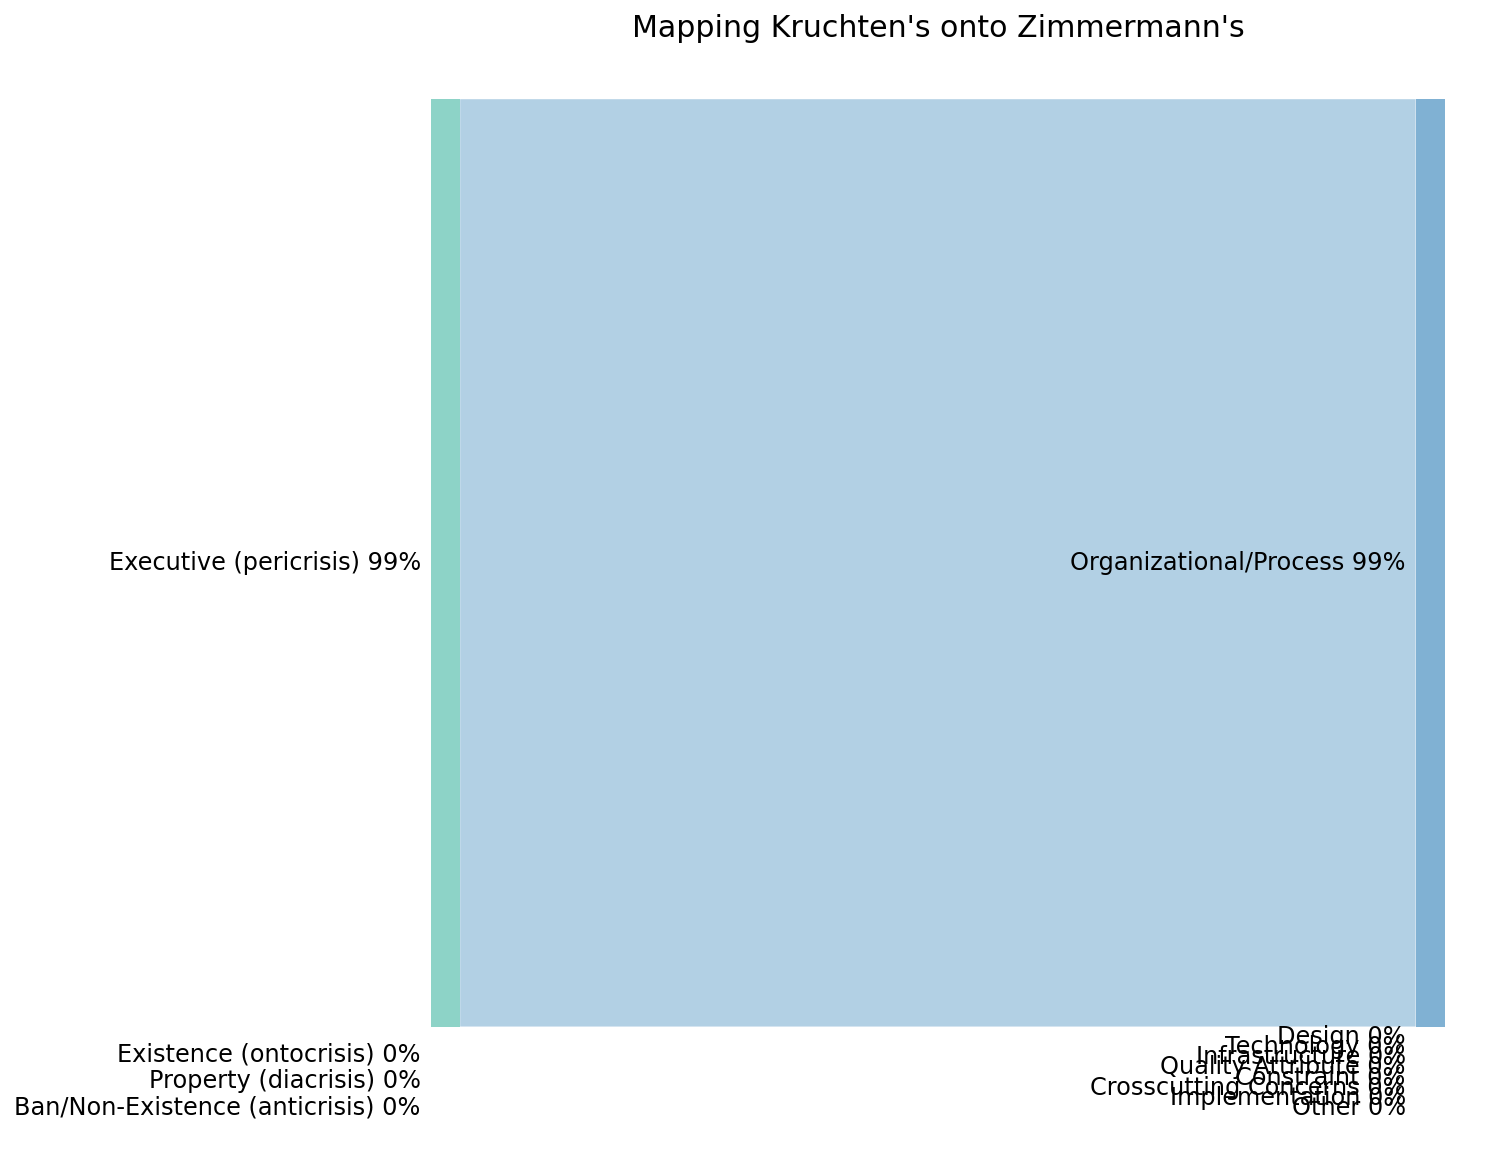

In [21]:
nodes1, flows1 = create_nodes_and_flows(
    classification_df,
    'kruchten_primary_category',
    'zimmermann_primary_category',
)

title = "Mapping Kruchten's onto Zimmermann's"
make_sankey(nodes1, flows1, palette=COMMON_PALETTE, title=title)


c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\sankeyflow\sankeyflow.py:72: RuntimeWarning: invalid value encountered in scalar divide
  value_scale = self.value / (self.height - self.flow_pad * (len(flows) - 1))


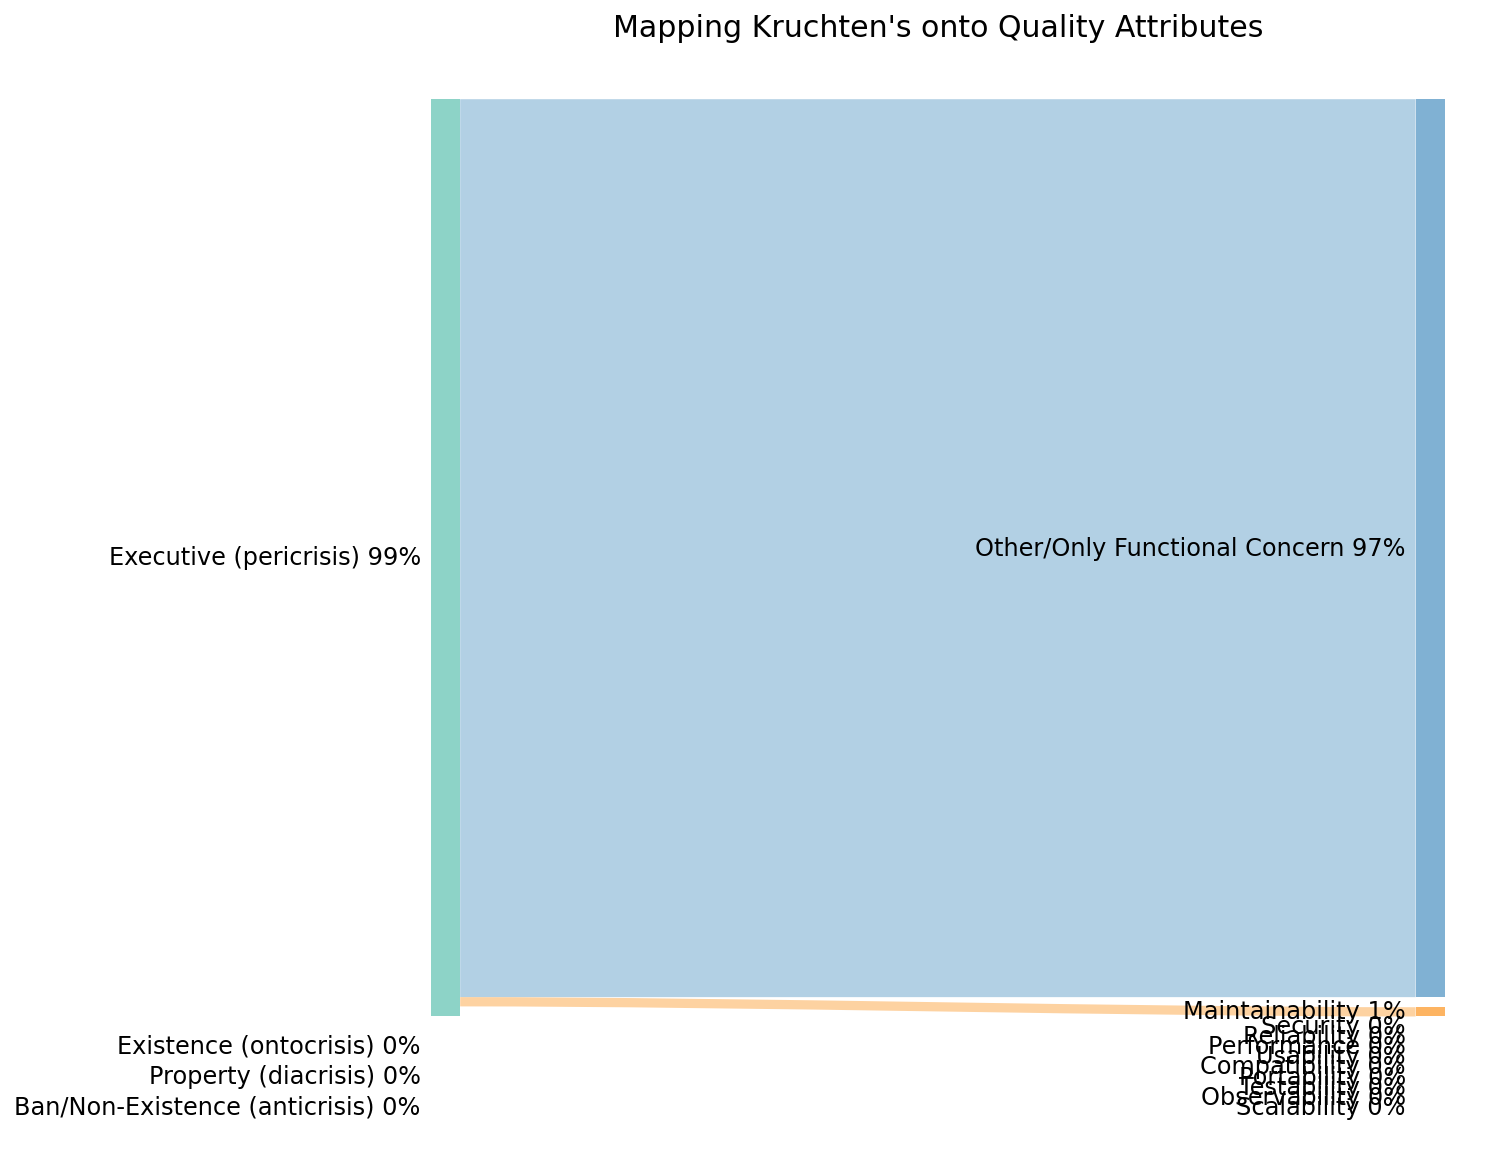

In [22]:
nodes2, flows2 = create_nodes_and_flows(
    classification_df,
    'kruchten_primary_category',
    'qa_primary_category',
)

title = "Mapping Kruchten's onto Quality Attributes"
make_sankey(nodes2, flows2, palette=COMMON_PALETTE, title=title)


c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\sankeyflow\sankeyflow.py:72: RuntimeWarning: invalid value encountered in scalar divide
  value_scale = self.value / (self.height - self.flow_pad * (len(flows) - 1))


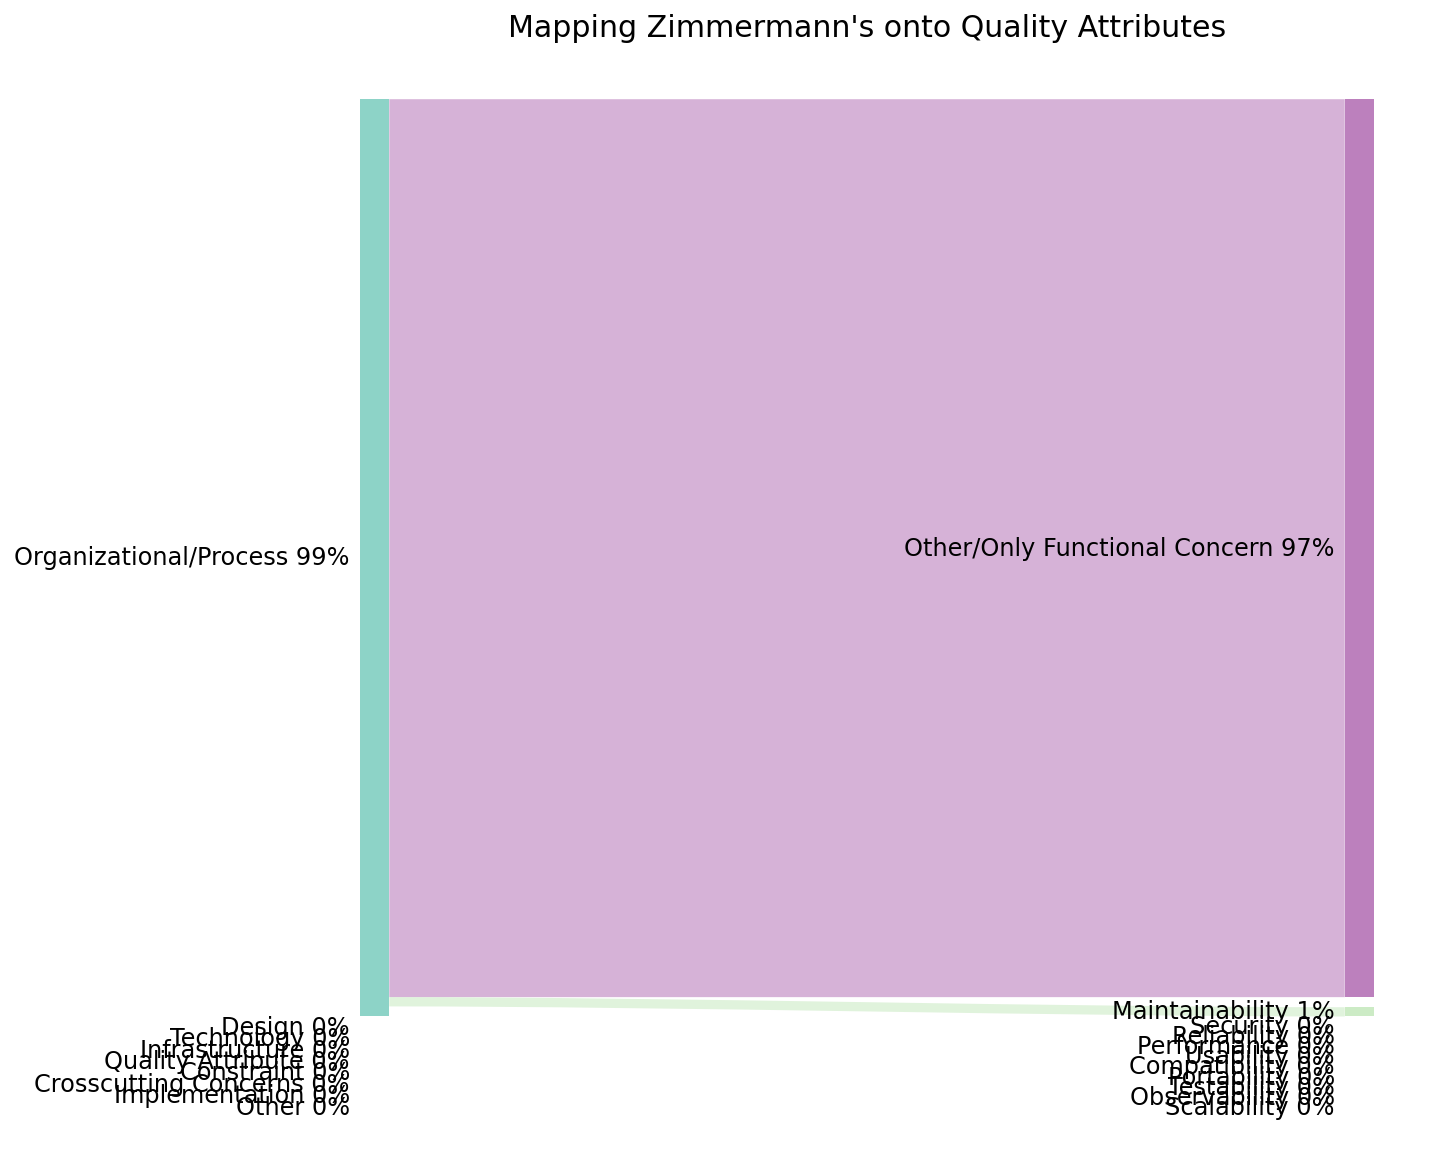

In [23]:
nodes3, flows3 = create_nodes_and_flows(
    classification_df,
    'zimmermann_primary_category',
    'qa_primary_category',
)

title = "Mapping Zimmermann's onto Quality Attributes"
make_sankey(nodes3, flows3, palette=COMMON_PALETTE, title=title)


## 9. Relationships with mined topics

This section loads the dominant-topic assignment for each ADR. Descriptive LLM-generated
labels are used when available; otherwise, the notebook falls back to KeyBERT or keyword
representations.

Topics representing less than the configured corpus threshold are grouped as
`Others` to keep the charts readable.

In [24]:
topics_dict_list = load_json_results(
    TOPICS_RESULTS,
    'Topic-assignment',
)
topics_dict_list[:5]


4316 Topic-assignment ADR results loaded


[{'text': '# Use Markdown Architectural Decision Records\n\n## Context and Problem Statement\n\nWe want to record architectural decisions made in this project.\nWhich format and structure should these records follow?\n\n## Considered Options\n\n* [MADR](https://adr.github.io/madr/) 2.1.2 – The Markdown Architectural Decision Records\n* [Michael Nygard\'s template](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions) – The first incarnation of the term "ADR"\n* [Sustainable Architectural Decisions](https://www.infoq.com/articles/sustainable-architectural-design-decisions) – The Y-Statements\n* Other templates listed at <https://github.com/joelparkerhenderson/architecture_decision_record>\n* Formless – No conventions for file format and structure\n\n## Decision Outcome\n\nChosen option: "MADR 2.1.2", because\n\n* Implicit assumptions should be made explicit.\nDesign documentation is important to enable people understanding the decisions later on.\nSee also [A rat

In [25]:
topics_df = pd.json_normalize(topics_dict_list)

def first_value(value):
    """Unwrap BERTopic list-valued representations when necessary."""
    if isinstance(value, list):
        return value[0] if value else None
    return value

for column in [
    'keywords',
    'keybert_representation',
    'openai_representation',
]:
    if column in topics_df.columns:
        topics_df[column] = topics_df[column].apply(first_value)

# The archived topic results use this descriptive label field.
topic_label_field = 'openai_representation'
if topic_label_field not in topics_df.columns:
    raise KeyError(
        f"Expected topic-label field {topic_label_field!r} was not found "
        "in the configured topic result file."
    )

print('Topic label field:', topic_label_field)
print(
    topics_df[topic_label_field].nunique(),
    'topics identified in ADRs',
)
topics_df.head()


Topic label field: openai_representation
73 topics identified in ADRs


,text,topics,keywords,keybert_representation,openai_representation,probabilities,metadata.organization,metadata.project,metadata.adr_key
0,# Use Markdown Architectural Decision Records\...,[2],"[architecture_decision_record, adrs, adr, arch...",2_architecture_decision_record_adrs_adr_archit...,Frontend architecture and UI component redesign,[0.7749036550521851],VolleyManagement,volley-management,0000-use-markdown-architectural-decision-recor...
1,# Use Auth0 as authentication provider\n\n* St...,[10],"[authentication, oauth2, authenticate, oauth, ...",10_authentication_oauth2_authenticate_oauth,Cosmos SDK Module Interactions and Encoding St...,[0.6686123609542847],VolleyManagement,volley-management,0001-use-auth0-as-authentication-provider.md
2,# Use SendGrid for sending emails\n\n* Status:...,[27],"[notifications, emails, alerts, notification, ...",27_notifications_emails_alerts_notification,iOS Build Modernization and Testing Best Pract...,[0.5629212260246277],VolleyManagement,volley-management,0002-use-sendgrid-as-mailing-system.md
3,# Use Angular Framework for VolleyManagement.S...,[42],"[apis, azure, apigee, api, gateway, cloud, ope...",42_apis_azure_apigee_api,JavaScript Code Style and Linting Enforcement,[0.35858237743377686],VolleyManagement,volley-management,0003-use-angular-for-spa.md
4,# Use Docker for hosting application\n\n* Stat...,[5],"[docker, dockerfiles, dockerfile, containers, ...",5_docker_dockerfiles_dockerfile_containers,Software Release Management and Branching Stra...,[0.6405783891677856],VolleyManagement,volley-management,0004-use-docker-for-hosting-application.md


In [26]:
# Analysis configuration:
# Group low-frequency topic labels to improve chart readability.
# More advanced association measures, such as Cramer's V, can be added in
# follow-up analyses.


In [27]:
frequencies = topics_df[topic_label_field].value_counts(
    normalize=True
)
infrequent_values = frequencies[
    frequencies < TOPIC_FREQUENCY_THRESHOLD
].index

topics_df['topic_label_cleaned'] = topics_df[
    topic_label_field
].mask(
    topics_df[topic_label_field].isin(infrequent_values),
    'Others',
)

print(
    f"Topics below {TOPIC_FREQUENCY_THRESHOLD:.1%} "
    "of the corpus were grouped as 'Others'."
)


Topics below 2.0% of the corpus were grouped as 'Others'.


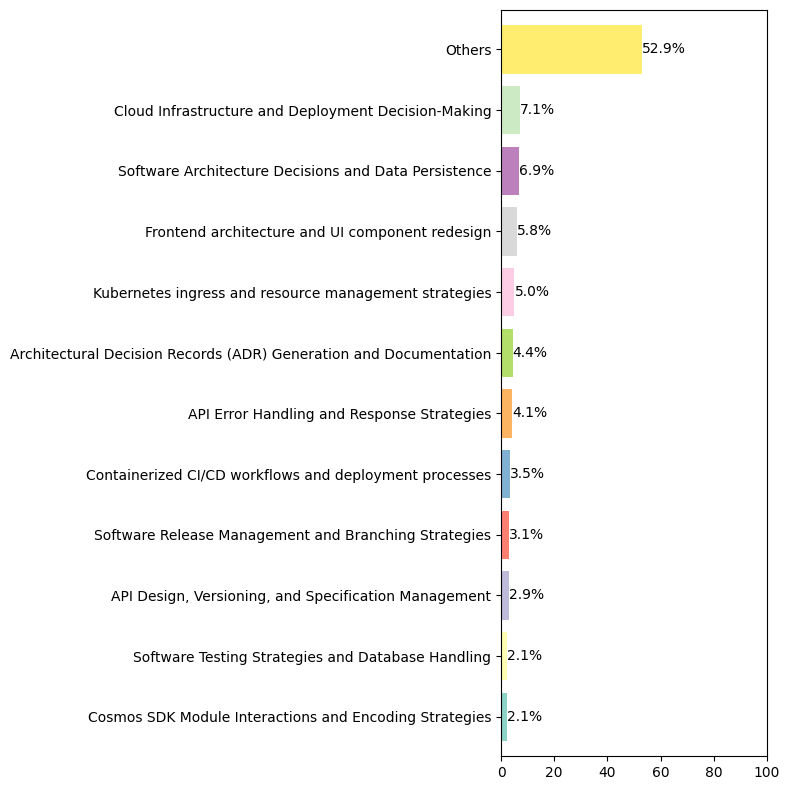

In [28]:
create_bar_chart(
    topics_df,
    palette=COMMON_PALETTE,
    category_column='topic_label_cleaned',
    fig_size=(8, 8),
)


In [29]:
# Keep the ADR identifier and cleaned topic label.
#
# Prefer metadata.adr_key when available because it matches the classification
# result files. Fall back to text only for legacy topic outputs.
if 'metadata.adr_key' in topics_df.columns:
    topic_categories = (
        topics_df[['metadata.adr_key', 'topic_label_cleaned']]
        .dropna()
        .rename(
            columns={
                'metadata.adr_key': 'adr_key',
                'topic_label_cleaned': 'topics_primary_category',
            }
        )
    )
elif 'adr_key' in topics_df.columns:
    topic_categories = (
        topics_df[['adr_key', 'topic_label_cleaned']]
        .dropna()
        .rename(
            columns={
                'topic_label_cleaned': 'topics_primary_category',
            }
        )
    )
else:
    raise KeyError(
        'Topic results do not contain an ADR key. '
        'Regenerate them with metadata.adr_key to align topics with classifications.'
    )

print(topic_categories.shape)
topic_categories.head()


(4316, 2)


,adr_key,topics_primary_category
0,0000-use-markdown-architectural-decision-recor...,Frontend architecture and UI component redesign
1,0001-use-auth0-as-authentication-provider.md,Cosmos SDK Module Interactions and Encoding St...
2,0002-use-sendgrid-as-mailing-system.md,Others
3,0003-use-angular-for-spa.md,Others
4,0004-use-docker-for-hosting-application.md,Software Release Management and Branching Stra...


In [30]:
# Align the topic assignments with the three taxonomy classifications.
classification_topics_df = classification_df.merge(
    topic_categories,
    on='adr_key',
    how='inner',
)

print(
    classification_topics_df.shape,
    'ADRs shared by classification and topic result sets',
)
classification_topics_df.head()


(224555712, 5) ADRs shared by classification and topic result sets


,adr_key,zimmermann_primary_category,kruchten_primary_category,qa_primary_category,topics_primary_category
0,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern,Frontend architecture and UI component redesign
1,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern,Frontend architecture and UI component redesign
2,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern,Frontend architecture and UI component redesign
3,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern,Frontend architecture and UI component redesign
4,0001-record-architecture-decisions.md,Organizational/Process,Executive (pericrisis),Other/Only Functional Concern,Frontend architecture and UI component redesign


c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\sankeyflow\sankeyflow.py:72: RuntimeWarning: invalid value encountered in scalar divide
  value_scale = self.value / (self.height - self.flow_pad * (len(flows) - 1))


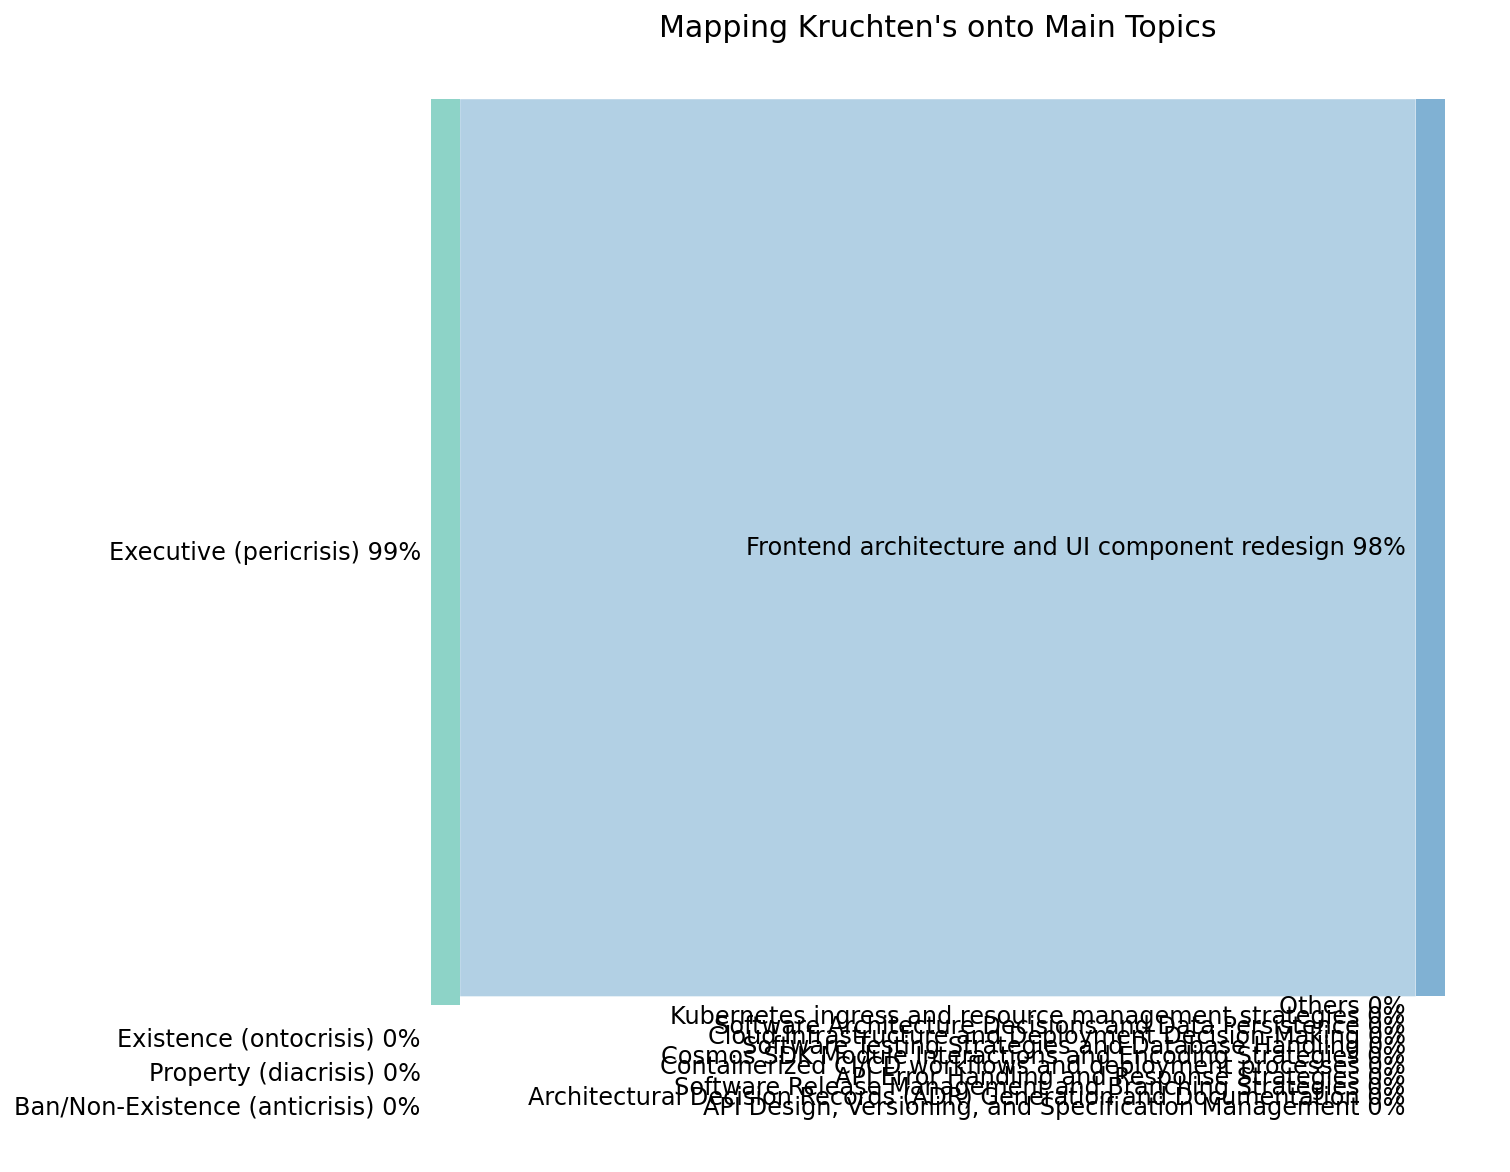

In [31]:
nodes4, flows4 = create_nodes_and_flows(
    classification_topics_df,
    'kruchten_primary_category',
    'topics_primary_category',
)

title = "Mapping Kruchten's onto Main Topics"
make_sankey(nodes4, flows4, palette=COMMON_PALETTE, title=title)


## 10. MADR template checks

This section loads the ADR-checking results and summarizes four criteria for five key
MADR sections:

- section presence;
- alternative title;
- content quality; and
- purpose consistency.

`Partial` purpose consistency is treated as satisfactory, matching the analysis reported
in the companion paper.

In [32]:
compliance_classification_dict_list = load_json_results(
    COMPLIANCE_RESULTS,
    'MADR-checking',
)
compliance_classification_dict_list[:5]


4209 MADR-checking ADR results loaded


[{'section_assessments': [{'section_name': 'Context',
    'presence': 'Yes',
    'content_quality': 'No',
    'purpose_consistency': 'Yes',
    'justification': "The ADR includes a section titled 'Context', so presence is 'Yes'. However, the content is minimal and generic: 'We need to record the architectural decisions made on this project.' This is a vague statement and does not provide meaningful, project-specific background, system state, problem, or motivation. Despite the minimal content, it does not include detailed comparisons, rationales, or final decisions, so the purpose consistency is 'Yes'. There are no alternate titles fulfilling this role, so the list is empty.",
    'alternate_title': []},
   {'section_name': 'Decision',
    'presence': 'Yes',
    'content_quality': 'Yes',
    'purpose_consistency': 'Yes',
    'justification': "The ADR includes a section titled exactly 'Decision', fulfilling the presence criterion. The content clearly states the final choice made: to use

In [33]:
def check_alternate_title(row, column):
    """Return True when an absent expected heading has an alternative title."""
    prefix = column.split('.')[0]
    presence_column = prefix + '.presence'
    alternate_titles = row[column]

    if row[presence_column] == 'No':
        return bool(
            isinstance(alternate_titles, list)
            and len(alternate_titles) > 0
        )

    return False


def summarize_results(
    df: pd.DataFrame,
    selector,
    n_decimals: int = 2,
    adr_sections=None,
    criteria=None,
):
    """Compute the percentage of ADRs satisfying each section criterion."""
    if adr_sections is None:
        adr_sections = [
            'context',
            'drivers',
            'decision',
            'consequences',
            'options',
        ]
    if criteria is None:
        criteria = [
            'alternative title?',
            'content quality',
            'present?',
            'purpose consistency',
        ]

    aspects_df = df[selector].copy()

    alternate_title_columns = [
        column
        for column in aspects_df.columns
        if column.endswith('alternate_title')
    ]
    for column in alternate_title_columns:
        aspects_df[column] = aspects_df.apply(
            lambda row: check_alternate_title(row, column),
            axis=1,
        )

    # Match the paper analysis: Partial purpose consistency is satisfactory.
    aspects_df = (
        aspects_df
        .replace({'Yes': True, 'No': False, 'Partial': True})
        .astype(bool)
    )

    percentages = aspects_df.sum(axis=0) / aspects_df.shape[0] * 100
    percentages.index = pd.MultiIndex.from_tuples(
        [tuple(column.split('.')) for column in percentages.index]
    )

    results_df = (
        percentages
        .unstack()
        .round(n_decimals)
        .reindex(adr_sections)
    )
    results_df.columns = criteria
    return results_df


def create_heatmap(
    df,
    figsize=(10, 8),
    title="",
    criteria_order=None,
):
    """Render section-level compliance percentages as a heatmap."""
    if criteria_order is None:
        criteria_order = [
            'present?',
            'alternative title?',
            'content quality',
            'purpose consistency',
        ]

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        df[criteria_order],
        annot=True,
        cmap='YlGn',
        fmt='.2f',
        linewidths=.5,
        cbar_kws={'label': 'Percentage (%)'},
        vmax=100,
        vmin=0,
    )
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        ha='right',
    )
    plt.title(title)
    plt.show()


In [34]:
# Flatten nested section assessments into one dataframe.
compliance_df = pd.json_normalize(
    compliance_classification_dict_list
)

section_assessments_df = pd.json_normalize(
    compliance_df['section_assessments']
)
adr_sections = [
    'context',
    'decision',
    'consequences',
    'drivers',
    'options',
]
section_assessments_df.columns = adr_sections

section_dfs = []
for section in adr_sections:
    section_df = pd.json_normalize(
        section_assessments_df[section]
    ).add_prefix(section + '.')
    section_dfs.append(section_df)

compliance_flat_df = pd.concat(
    [
        compliance_df.drop('section_assessments', axis=1),
        *section_dfs,
    ],
    axis=1,
).dropna(axis=0)

print(compliance_flat_df.shape)
compliance_flat_df.head()


(4209, 43)


,template_adherence.title,template_adherence.status,template_adherence.context,template_adherence.decision_drivers,template_adherence.decision,template_adherence.consequences,template_adherence.alternatives,template_adherence.date,template_adherence.adherence_score,template_adherence.assessment,...,drivers.content_quality,drivers.purpose_consistency,drivers.justification,drivers.alternate_title,options.section_name,options.presence,options.content_quality,options.purpose_consistency,options.justification,options.alternate_title
0,0. Record architecture decisions,accepted,We need to record the architectural decisions ...,,"We will use Architecture Decision Records, as ...","See Michael Nygard's article, linked above.",[],,0.83,- Title: Present and appropriate as the main h...,...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,The ADR does not include a section titled 'Con...,[]
1,1. The Katas follow the here described formatting,accepted,I come back to the katas and my formatting sty...,,A kata looks like the following:\n\n```\ndescr...,All katas look alike and the users have one UX...,[],,0.70,- Title: Present and appropriate as the first ...,...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,There is no section titled 'Considered Options...,[]
2,Assessment of ADR '2. We don't use any linter'...,accepted,The ADR discusses the decision not to use a li...,The ADR considers the overhead of configuring ...,The decision is to not use a linter but rely o...,"The consequence is that no linter is used, and...",[{'description': 'Use a traditional linter wit...,2024-06-10,0.80,- Title: Present and descriptive ('2. We don't...,...,No,No,The ADR does not include a section titled 'Dec...,[],Considered Options,No,No,No,The ADR does not include a section titled 'Con...,[]
3,3. Katafication,accepted,All katas in here are supposed to be used to f...,,All tests have to pass and the special comment...,The tests can be used as tests and katas. Addi...,[],,0.71,"- Title: Present as '3. Katafication', which i...",...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,There is no section titled 'Considered Options...,[]
4,"4. In-depth katas are separated from ""normal"" ...",Accepted,I (Wolfram) am writing most of the katas and s...,- Need to handle different depths of katas (si...,Katas will come in two flavours: simple kata a...,- There will be more katas overall.\n- Simple ...,[{'description': 'Maintain a single kata per f...,2024-06-10,0.90,- Title: Present and appropriate as the main h...,...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,The ADR does not include a section titled 'Con...,[]


In [35]:
# Inspect the available flattened columns when adapting the checking schema.
# print(compliance_flat_df.columns.tolist())

In [36]:
section_order = [
    'context',
    'drivers',
    'decision',
    'consequences',
    'options',
]
aspects = [
    'presence',
    'alternate_title',
    'content_quality',
    'purpose_consistency',
]

col_aspect_selector = [
    f'{section}.{aspect}'
    for section in section_order
    for aspect in aspects
]


C:\Users\AK128882\AppData\Local\Temp\ipykernel_224124\643176710.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'Yes': True, 'No': False, 'Partial': True})


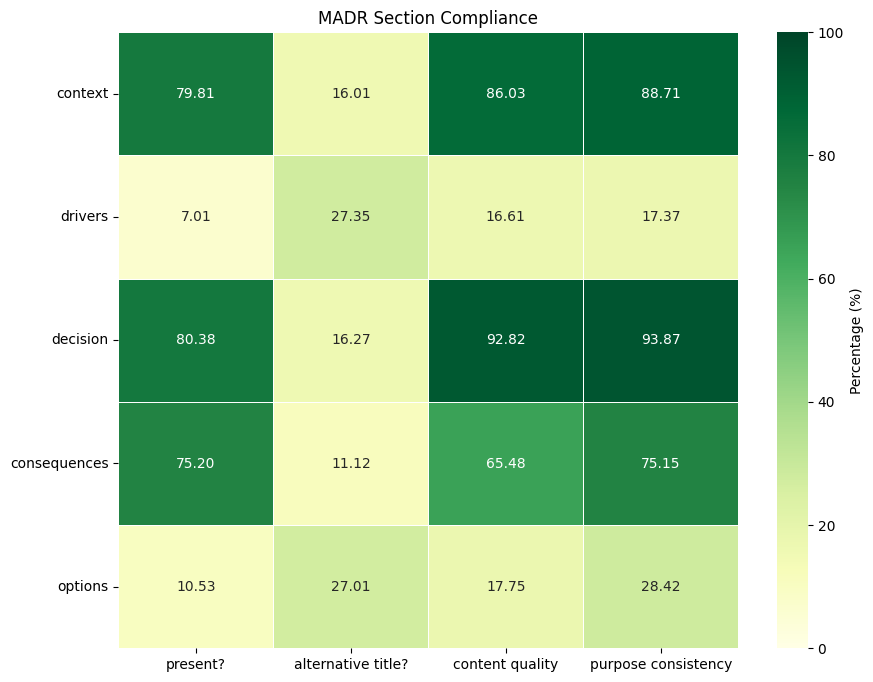

In [37]:
results_df = summarize_results(
    compliance_flat_df,
    col_aspect_selector,
)
create_heatmap(
    results_df,
    title='MADR Section Compliance',
)


In [38]:
# Numerical percentages underlying the compliance heatmap.
results_df


,alternative title?,content quality,present?,purpose consistency
context,16.01,86.03,79.81,88.71
drivers,27.35,16.61,7.01,17.37
decision,16.27,92.82,80.38,93.87
consequences,11.12,65.48,75.20,75.15
options,27.01,17.75,10.53,28.42


---

## 11. Expected results and reuse

After running the notebook, users should obtain the category-distribution plots,
cross-framework Sankey diagrams, topic mappings, and MADR-compliance heatmap used in
the study.

To analyze another experiment or dataset, update the configured input paths while
keeping the archived result files unchanged so that the original study remains
reproducible.
